# ARIMA & SARIMA Forecasting
## Table of Contents

* **Section 1:** Imports
* **Section 2:** Load Data
* **Section 3:** Create Daily Sales Series
* **Section 4:** Train-Test Split
* **Section 5:** Stationarity Test (ADF)
* **Section 6:** ACF & PACF Analysis
* **Section 7:** ADF Interpretation
* **Section 8:** ARIMA(1,0,1)
* **Section 9:** ARIMA Evaluation
* **Section 10:** SARIMA(1,0,1)(1,0,1,7)
* **Section 11:** SARIMA Evaluation
* **Section 12:** SARIMA(5,0,0)(1,0,1,7)
* **Section 13:** SARIMA(5,0,0)(1,0,1,7) Evaluation
* **Section 14:** Model Comparison
* **Section 15:** Phase 2 Findings

In [1]:
# ============================================================
# SECTION 1: IMPORTS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import warnings
warnings.filterwarnings("ignore")

In [2]:
# ============================================================
# SECTION 2: LOAD DATA
# ============================================================

train = pd.read_csv(
    "../data/raw/train.csv",
    low_memory=False
)

train["Date"] = pd.to_datetime(
    train["Date"]
)

print(train.shape)
train.head()

(1017209, 9)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [3]:
# ============================================================
# SECTION 3: CREATE DAILY SALES SERIES
# ============================================================

daily_sales = (
    train.groupby("Date")["Sales"]
    .sum()
    .reset_index()
)

daily_sales = daily_sales.set_index("Date")

daily_sales = daily_sales.asfreq("D")

print(daily_sales.shape)

daily_sales.head()

(942, 1)


,Sales
Date,
2013-01-01,97235
2013-01-02,6949829
2013-01-03,6347820
2013-01-04,6638954
2013-01-05,5951593


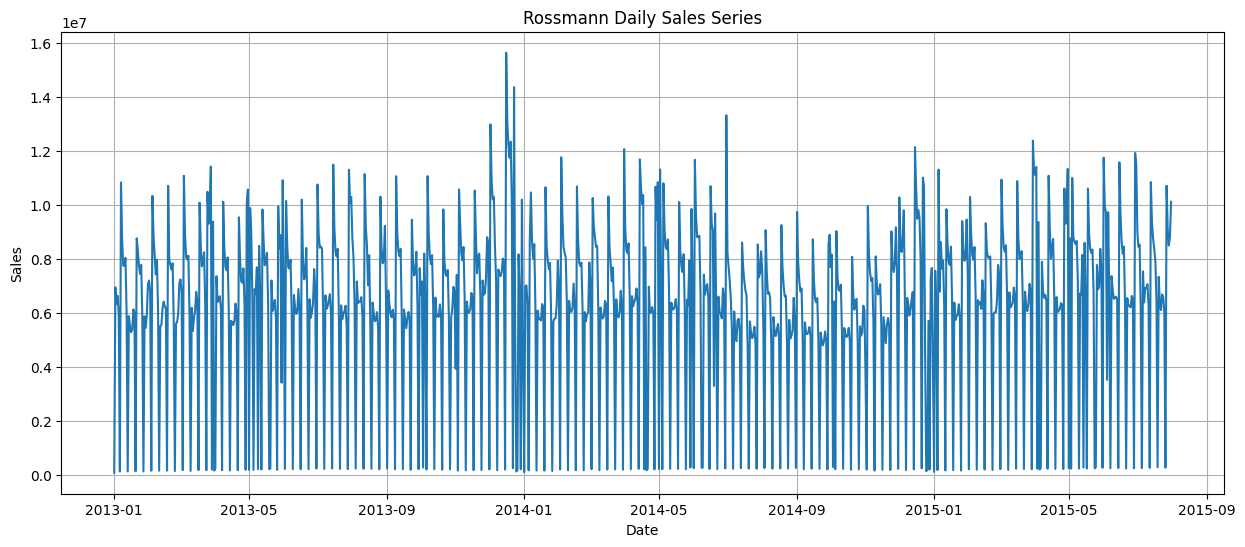

In [4]:
# ============================================================
# SECTION 4: VISUALIZE TIME SERIES
# ============================================================

plt.figure(figsize=(15,6))

plt.plot(
    daily_sales.index,
    daily_sales["Sales"]
)

plt.title(
    "Rossmann Daily Sales Series"
)

plt.xlabel("Date")
plt.ylabel("Sales")

plt.grid()

plt.show()

In [5]:
# ============================================================
# SECTION 5: ADF TEST
# ============================================================

result = adfuller(
    daily_sales["Sales"]
)

print("ADF Statistic :", result[0])
print("P-value       :", result[1])
print("Lags Used     :", result[2])
print("Observations  :", result[3])

ADF Statistic : -4.761614524595634
P-value       : 6.436731330558783e-05
Lags Used     : 20
Observations  : 921


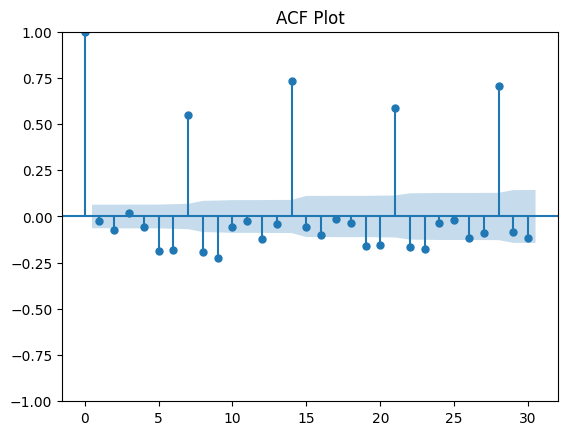

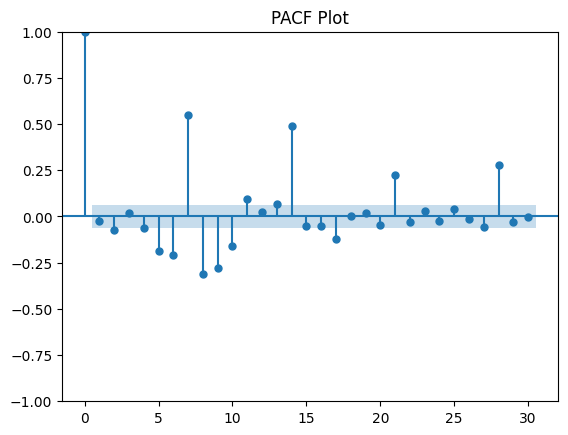


ACF VALUES
    Lag     ACF
0     0  1.0000
1     1 -0.0252
2     2 -0.0708
3     3  0.0213
4     4 -0.0566
5     5 -0.1862
6     6 -0.1807
7     7  0.5466
8     8 -0.1910
9     9 -0.2255
10   10 -0.0593
11   11 -0.0220
12   12 -0.1199
13   13 -0.0434
14   14  0.7316
15   15 -0.0559
16   16 -0.0981
17   17 -0.0120
18   18 -0.0376
19   19 -0.1572
20   20 -0.1564
21   21  0.5876
22   22 -0.1632
23   23 -0.1746
24   24 -0.0372
25   25 -0.0192
26   26 -0.1190
27   27 -0.0910
28   28  0.7039
29   29 -0.0819
30   30 -0.1147

PACF VALUES
    Lag    PACF
0     0  1.0000
1     1 -0.0252
2     2 -0.0716
3     3  0.0178
4     4 -0.0612
5     5 -0.1892
6     6 -0.2119
7     7  0.5519
8     8 -0.3182
9     9 -0.2826
10   10 -0.1623
11   11  0.0975
12   12  0.0243
13   13  0.0660
14   14  0.5058
15   15 -0.0594
16   16 -0.0620
17   17 -0.1297
18   18  0.0066
19   19  0.0196
20   20 -0.0470
21   21  0.2449
22   22 -0.0337
23   23  0.0281
24   24 -0.0322
25   25  0.0451
26   26 -0.0185
27   27 -0.0685

In [10]:
# ============================================================
# SECTION 6: ACF & PACF ANALYSIS
# ============================================================

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf

# ------------------------------------------------------------
# ACF Plot
# ------------------------------------------------------------

plot_acf(
    daily_sales["Sales"],
    lags=30
)

plt.title("ACF Plot")
plt.show()


# ------------------------------------------------------------
# PACF Plot
# ------------------------------------------------------------

plot_pacf(
    daily_sales["Sales"],
    lags=30,
    method="ywm"
)

plt.title("PACF Plot")
plt.show()


# ------------------------------------------------------------
# Numerical ACF Values
# ------------------------------------------------------------

acf_values = acf(
    daily_sales["Sales"],
    nlags=30
)

acf_df = pd.DataFrame({
    "Lag": range(len(acf_values)),
    "ACF": acf_values
})

print("\n" + "="*60)
print("ACF VALUES")
print("="*60)
print(acf_df.round(4))


# ------------------------------------------------------------
# Numerical PACF Values
# ------------------------------------------------------------

pacf_values = pacf(
    daily_sales["Sales"],
    nlags=30
)

pacf_df = pd.DataFrame({
    "Lag": range(len(pacf_values)),
    "PACF": pacf_values
})

print("\n" + "="*60)
print("PACF VALUES")
print("="*60)
print(pacf_df.round(4))


# ------------------------------------------------------------
# Top Significant ACF Lags
# ------------------------------------------------------------

print("\n" + "="*60)
print("TOP 10 ACF LAGS")
print("="*60)

print(
    acf_df.iloc[1:]
    .sort_values("ACF", ascending=False)
    .head(10)
    .round(4)
)


# ------------------------------------------------------------
# Top Significant PACF Lags
# ------------------------------------------------------------

print("\n" + "="*60)
print("TOP 10 PACF LAGS")
print("="*60)

print(
    pacf_df.iloc[1:]
    .sort_values("PACF", ascending=False)
    .head(10)
    .round(4)
)


# ------------------------------------------------------------
# Weekly Seasonality Check
# ------------------------------------------------------------

print("\n" + "="*60)
print("SEASONALITY CHECK")
print("="*60)

for lag in [7, 14, 21, 28]:
    print(
        f"Lag {lag}: "
        f"ACF = {acf_values[lag]:.4f}"
    )

In [13]:
# ============================================================
# SECTION 7: INTERPRET ADF TEST
# ============================================================

adf_result = adfuller(
    daily_sales["Sales"]
)

p_value = adf_result[1]

print("ADF P-value:", p_value)

if p_value < 0.05:
    print("\nSeries is stationary.")
    print("Differencing is not required.")
else:
    print("\nSeries is non-stationary.")
    print("Differencing is required.")

ADF P-value: 6.436731330558783e-05

Series is stationary.
Differencing is not required.


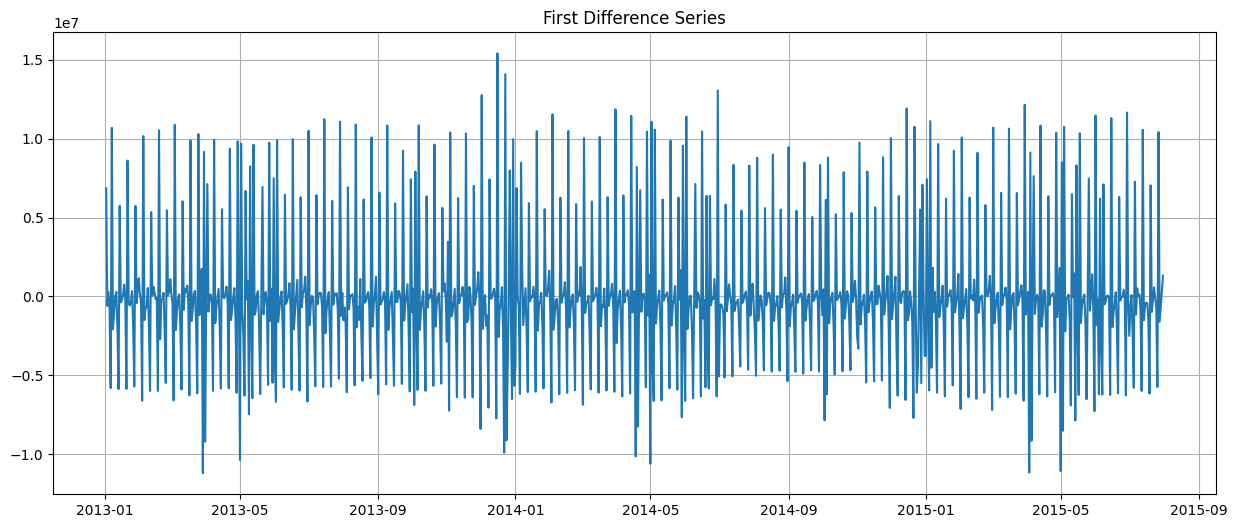

In [14]:
# ============================================================
# SECTION 8: FIRST DIFFERENCE ANALYSIS
# ============================================================

daily_sales["Sales_Diff"] = (
    daily_sales["Sales"].diff()
)

plt.figure(figsize=(15,6))

plt.plot(
    daily_sales.index,
    daily_sales["Sales_Diff"]
)

plt.title("First Difference Series")

plt.grid()

plt.show()

In [15]:
# ============================================================
# SECTION 9: ADF AFTER DIFFERENCING
# ============================================================

diff_series = (
    daily_sales["Sales"]
    .diff()
    .dropna()
)

result_diff = adfuller(
    diff_series
)

print("ADF Statistic :", result_diff[0])
print("P-value       :", result_diff[1])

ADF Statistic : -14.008528601649742
P-value       : 3.7500440046049845e-26


In [16]:
# ============================================================
# SECTION 10: TRAIN TEST SPLIT
# ============================================================

train_series = daily_sales.iloc[:-90]

test_series = daily_sales.iloc[-90:]

print("Train Size:", len(train_series))
print("Test Size :", len(test_series))

Train Size: 852
Test Size : 90


In [17]:
# ============================================================
# SECTION 11: ARIMA(1,0,1)
# ============================================================

from statsmodels.tsa.arima.model import ARIMA

arima_101 = ARIMA(
    train_series["Sales"],
    order=(1,0,1)
)

arima_101_fit = arima_101.fit()

arima_101_pred = arima_101_fit.forecast(
    steps=len(test_series)
)

print(arima_101_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                  852
Model:                 ARIMA(1, 0, 1)   Log Likelihood              -13942.833
Date:                Thu, 16 Jul 2026   AIC                          27893.666
Time:                        20:53:18   BIC                          27912.657
Sample:                    01-01-2013   HQIC                         27900.940
                         - 05-02-2015                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       6.189e+06   7.93e+04     78.027      0.000    6.03e+06    6.34e+06
ar.L1          0.7508      0.118      6.355      0.000       0.519       0.982
ma.L1         -0.8222      0.099     -8.269      0.0

In [18]:
# ============================================================
# EVALUATE ARIMA(1,0,1)
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

mae = mean_absolute_error(
    test_series["Sales"],
    arima_101_pred
)

rmse = np.sqrt(
    mean_squared_error(
        test_series["Sales"],
        arima_101_pred
    )
)

mape = mean_absolute_percentage_error(
    test_series["Sales"],
    arima_101_pred
) * 100

print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("MAPE:", round(mape,2))

MAE : 2520905.64
RMSE: 3264490.02
MAPE: 381.57


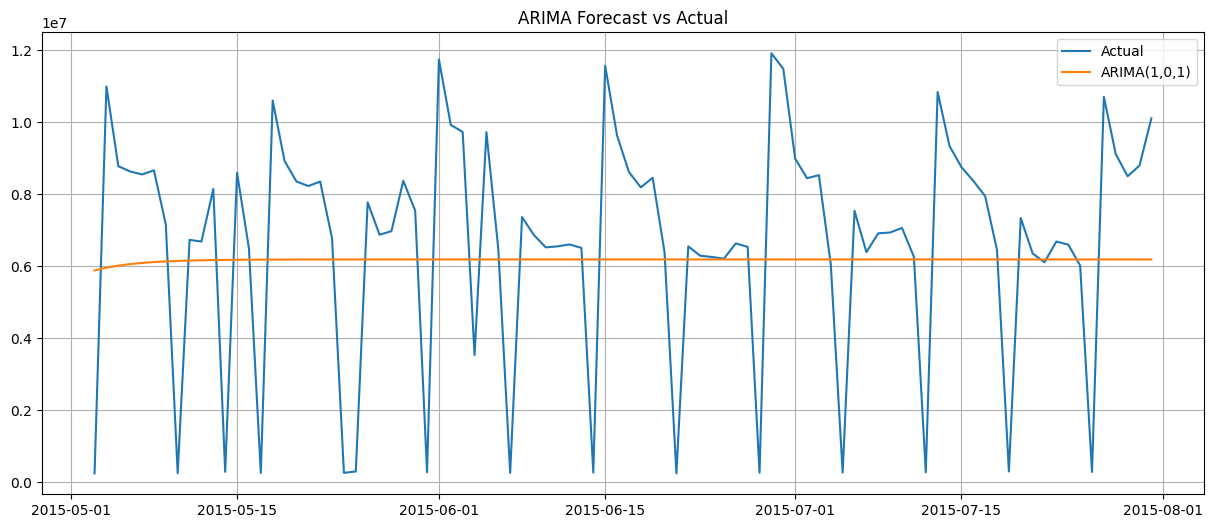

In [19]:
# ============================================================
# ARIMA(1,0,1) FORECAST
# ============================================================

plt.figure(figsize=(15,6))

plt.plot(
    test_series.index,
    test_series["Sales"],
    label="Actual"
)

plt.plot(
    test_series.index,
    arima_101_pred,
    label="ARIMA(1,0,1)"
)

plt.title("ARIMA Forecast vs Actual")

plt.legend()

plt.grid()

plt.show()

In [20]:
# ============================================================
# SECTION 12: SARIMA(1,0,1)(1,0,1,7)
# ============================================================

from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_101_101 = SARIMAX(
    train_series["Sales"],
    order=(1,0,1),
    seasonal_order=(1,0,1,7)
)

sarima_fit = sarima_101_101.fit()

sarima_pred = sarima_fit.forecast(
    steps=len(test_series)
)

print(sarima_fit.summary())

                                     SARIMAX Results                                     
Dep. Variable:                             Sales   No. Observations:                  852
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 7)   Log Likelihood              -13760.650
Date:                           Thu, 16 Jul 2026   AIC                          27531.300
Time:                                   20:54:44   BIC                          27555.038
Sample:                               01-01-2013   HQIC                         27540.392
                                    - 05-02-2015                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6789      0.203      3.346      0.001       0.281       1.077
ma.L1         -0.3892      0.230     -1.692

In [21]:
# ============================================================
# EVALUATE SARIMA
# ============================================================

mae = mean_absolute_error(
    test_series["Sales"],
    sarima_pred
)

rmse = np.sqrt(
    mean_squared_error(
        test_series["Sales"],
        sarima_pred
    )
)

mape = mean_absolute_percentage_error(
    test_series["Sales"],
    sarima_pred
) * 100

print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("MAPE:", round(mape,2))

MAE : 1302160.69
RMSE: 1913409.13
MAPE: 71.61


In [23]:
# ============================================================
# SECTION 13: SARIMA(5,0,0)(1,0,1,7)
# ============================================================

from statsmodels.tsa.statespace.sarimax import SARIMAX

# Build model
sarima_500 = SARIMAX(
    train_series["Sales"],
    order=(5, 0, 0),
    seasonal_order=(1, 0, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

# Train model
sarima_500_fit = sarima_500.fit()

# Model summary
print(sarima_500_fit.summary())

# Forecast next 90 days
sarima_500_pred = sarima_500_fit.forecast(
    steps=len(test_series)
)

                                      SARIMAX Results                                      
Dep. Variable:                               Sales   No. Observations:                  852
Model:             SARIMAX(5, 0, 0)x(1, 0, [1], 7)   Log Likelihood              -13544.267
Date:                             Thu, 16 Jul 2026   AIC                          27104.535
Time:                                     21:01:31   BIC                          27142.402
Sample:                                 01-01-2013   HQIC                         27119.048
                                      - 05-02-2015                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2543      0.078      3.247      0.001       0.101       0.408
ar.L2          0.2071      

In [24]:
# ============================================================
# EVALUATE SARIMA(5,0,0)(1,0,1,7)
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

mae = mean_absolute_error(
    test_series["Sales"],
    sarima_500_pred
)

rmse = np.sqrt(
    mean_squared_error(
        test_series["Sales"],
        sarima_500_pred
    )
)

mape = mean_absolute_percentage_error(
    test_series["Sales"],
    sarima_500_pred
) * 100

print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("MAPE:", round(mape, 2))

MAE : 1507592.87
RMSE: 2128379.78
MAPE: 86.62


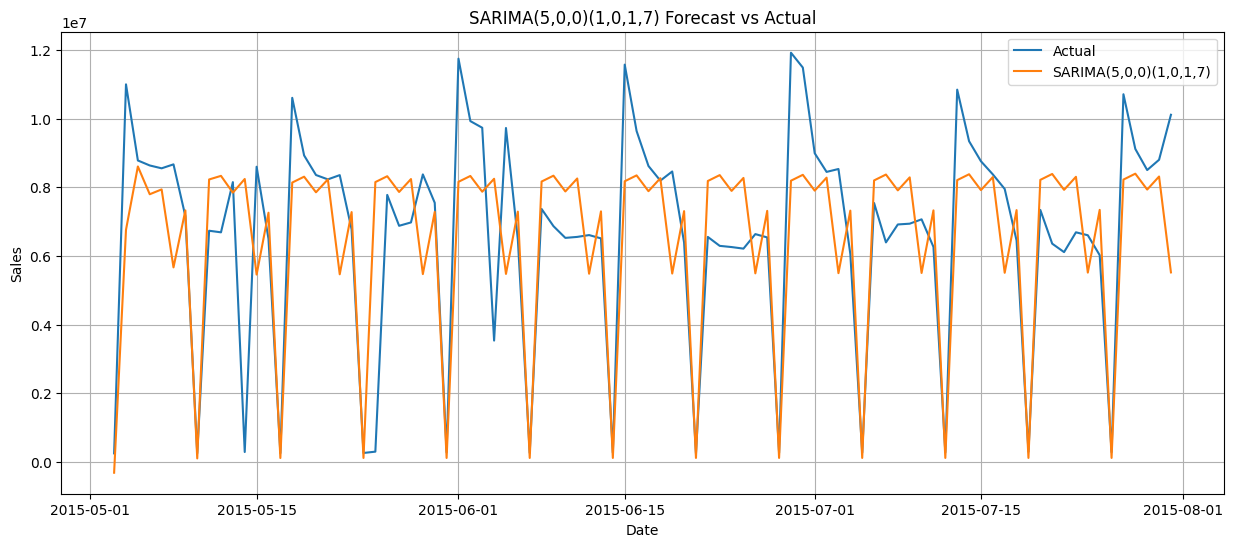

In [25]:
# ============================================================
# SARIMA(5,0,0)(1,0,1,7) FORECAST
# ============================================================

plt.figure(figsize=(15,6))

plt.plot(
    test_series.index,
    test_series["Sales"],
    label="Actual"
)

plt.plot(
    test_series.index,
    sarima_500_pred,
    label="SARIMA(5,0,0)(1,0,1,7)"
)

plt.title(
    "SARIMA(5,0,0)(1,0,1,7) Forecast vs Actual"
)

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.grid()

plt.show()